# Exercise 2: Calculate degassing paths

In this exercise we will calculate degassing paths applicable to the 2018 Lower East Rift Zone eruption of Kı̄lauea and compare it to melt and fluid inclusion data (Wieser et al., 2021; DeVitre & Wieser, 2024) using the tools VESIcal (Iacovino et al., 2021), VolFe (Hughes et al., 2025), Sulfur_X (Ding et al., 2023), and Evo (Liggins et al., 2020, Liggins et al., 2022) through the VICTOR platform (Lev et al., 2025) or locally if the required packages are installed.

<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b>🐣 &nbsp; To run locally</b><br> See the notebook <b><a href="0_Getting_Started.ipynb">0. Getting Started</a></b>. Always remember to ensure this notebook is running in the volatiles-gs-workshop26 conda environment!

<em>If you are running this on the VICTOR platform, all packages are already installed and you can skip this step. More information on VICTOR can be found at <a href="https://docs.victorproject.orgr/en/latest/index.html">https://docs.victorproject.orgr/en/latest/index.html</em></a>
</div>

## 1. Introduction
### 1.1 Import packages and note versions

In [1]:
# Packages that we will use in our code always get imported before we need them.
# This is canonically done at the top of a script.
# ⚠️ Note that this can take a few seconds if it's the first time you're importing these libraries.

import pandas as pd
import matplotlib.pyplot as plt
import VolFe as vf
import VESIcal as vc
import Thermobar as tb
import evo

/Users/kiacovino/miniconda3/envs/volatiles-gs-workshop26/lib/python3.11/site-packages/VESIcal/calculate_classes.py:7: UserWarning: 

  from VESIcal.models import magmasat


When reporting calculations in manuscripts, it's important to know which version of the Python package the results you are showing used - so we can output those below. This notebook was created using VolFe: 1.0.2 , VESIcal: 1.2.12 , Thermobar: 1.0.73 , pandas: 2.2.3, EVo: 1.1.0 (at git sha 2487939e18d98292f9b8f3a1f0dea04b707bd89f), and Sulfur_X 1.2 (git sha d605a34135c906c00f26de77b7e7f9abdb05d86f).

In [2]:
# print("VolFe " + vf.__version__ +", " +
#       "VESIcal ", VESIcal '+vc.__version__, ', Thermobar '+tb.__version__ '')
      
print(
    f"VolFe: {vf.__version__}",
    f"\nVESIcal: {vc.__version__}",
    f"\nThermobar: {tb.__version__}",
    f"\npandas: {pd.__version__}",
    )

VolFe: 1.0.2 
VESIcal: 1.2.12 
Thermobar: 1.0.73 
pandas: 2.2.3


### 1.2 Import data

We'll use the same melt inclusion dataset from notebook <a href="1_Calculate_Pressure_and_Fluid_Compositions.ipynb">1_Calculate_Pressure_and_Fluid_Compositions.ipynb</a>

In [3]:
# import melt inclusion dataset with temperatures calculated in notebook 1
MI = pd.read_csv("output/wieser2021_w_temperatures.csv")

# if you haven't run notebook 1, you can grab the "answer key" file from here:
# MI = pd.read_csv("files/wieser2021_w_temperatures.csv")


## 2. Initial melt composition

We choose the MI with the highest CO2 content as the starting point for the degassing calcuations

In [4]:
# row number with highest CO2 content
row = MI['Total CO2 (PEC-corrected) ppm'].idxmax()

print(f"The sample with the highest CO2 content is {row} with {MI['Total CO2 (PEC-corrected) ppm'][row]} ppm")

The sample with the highest CO2 content is 4 with 1405.0 ppm


We also specify the initial fO2 (DFMQ = 0.2 as before) and H2O = 0.5 wt%

In [5]:
DFMQ = 0.2
H2Oi = 0.5 # wt%

And combine this all into a single dictionary to use

In [6]:
ini_comp = MI.loc[row].to_dict()
ini_comp = {k.split(" ")[0]: v for k, v in ini_comp.items()}
ini_comp.update({
    "H2O": H2Oi,
    "CO2":   float(MI.loc[row, "Total CO2 (PEC-corrected) ppm"])
})

## 3. Calculate degassing path

Now we'll calculate degassing paths using various tools. In all our calculations we will assume closed-system degassing, but open-system degassing calculations are possible with all these tools. Additionally we'll assume isothermal (i.e., single temperature), no crystallisation, and that there is only melt at the beginning of the degassing path (i.e., no additional vapor).

### 3.1 VESIcal

For consistency, we'll use the same model options as before, but these can be changed!

In [7]:
# convert CO2 from ppm to wt%
ini_comp_wtpt = {key: val for key, val in ini_comp.items() if key in vc.oxides}
ini_comp_wtpt.update({"CO2": ini_comp_wtpt["CO2"]/10000.})

sample_vc = vc.Sample(ini_comp_wtpt)
# sample_vc.get_composition() # print composition if so desired

In [8]:
# run calculation
# temperature is specified in the function
results_degas_vc = vc.calculate_degassing_path(
    sample=sample_vc,
    temperature=float(MI.loc[row,'T_C']), # temperatures calculated by Thermobar in notebook 1
    model="IaconoMarziano").result

### 3.2 VolFe

VolFe requires additional inputs to VESIcal (S and fO2). Again, we'll use the same model options as before, but these can be changed if required.

In [10]:
# Define initial melt composition
sample_vf = ini_comp.copy()
sample_vf["CO2ppm"] = sample_vf.pop("CO2")
sample_vf["STppm"] = sample_vf.pop("S_MI_PEC")
sample_vf["DFMQ"] = DFMQ

sample_vf = pd.DataFrame(sample_vf, index=[0])

# define models
models_vf = [['water','Basalt_Hughes24'],['carbon dioxide','Basalt_Dixon97'],['sulfide','ONeill21dil'],['sulfate','ONeill22dil']]# IS there any other models and parameters that the users can choose/input? And how?
models_vf = vf.make_df_and_add_model_defaults(models_vf)

In [11]:
# run calculation
results_degas_vf = vf.calc_gassing(sample_vf, models = models_vf)

/Users/kiacovino/miniconda3/envs/volatiles-gs-workshop26/lib/python3.11/site-packages/VolFe/melt_gas.py:2059: UserWarning: you entered more than one way to infer iron speciation, note that this calcualtion is only considering the entered DFMQ
  w.warn(
  0%|          | 0/1 [00:00<?, ?it/s]


### 3..3 Sulfur_X

We can also run degassing calculations with Sulfur_X, which like VolFe includes S.

More information on Sulfur_X can be found at https://github.com/sdecho/Sulfur_X


First we have to define the directory where Sulfur_X is hosted

In [12]:
SulfurX_directory = 'Sulfur_X-main/'

Next we define the initial melt composition. We won't use it today, but the sulfide composition can be defined as well as the sulfur isotope ratio (these can also be used in VolFe). If crystallisation is required, this should also be defined.

In [13]:
# Temperature in C
temperature = float(MI.loc[row,'T_C'])

# fO2 relative to FMQ buffer
delta_FMQ = DFMQ

# initial H2O in wt.%
H2O_initial = ini_comp['H2O']

# initial CO2 in ppm
CO2_initial = ini_comp['CO2']

# initial sulfur in ppm
S_initial = float(MI.loc[row,'S_MI_PEC EPMA'])

# melt composition
sio2 = float(ini_comp['SiO2'])
al2o3 = float(ini_comp['Al2O3'])
feot = float(ini_comp['FeO'])
mgo = float(ini_comp['MgO'])
cao = float(ini_comp['CaO'])
na2o = float(ini_comp['Na2O'])
k2o = float(ini_comp['K2O'])
p2o5 = float(ini_comp['P2O5'])
mno = float(ini_comp['MnO'])
tio2 = float(ini_comp['TiO2'])

# Sulfide composition in wt%, only relevant if SCSS is of interest. 
sulfide = {"Fe": 65.43,
            "Ni": 0,
            "Cu": 0,
            "O": 0,
            "S": 36.47
            }

# initial sulfur isotope ratio
d34s_m_initial = 1

# if crystallization is enabled, H2O-melt fraction relation is specified using H2O-K2O relation (K2O = a * H2O +b),
# assuming K2O is perfectly incompatible. The given a and b are based on H2O-K2O relation for Fuego magma from
# Lloyd et al. (2013). Both H2O and K2O are in wt.%. If crystallization is disabled, or running on magmas similar to Fuego,
# leave them unchanged.
slope_h2o = -0.713
constant_h2o = 3.689

These parameters effect how the calculation is performed.

In [ ]:
# The total steps of pressure from initial P to 1 bar.
l = 1000

# Total number of runs along degassing
m = 1000

# Pressure threshold (in bar) below which the Kd_combined can increase with an arbiturary number defined by INC
BAR = 0

# Arbiturary increase of Kd_combined when pressure is lower than BAR (in bar) when BAR > 0; if BAR = 0, INC is not relevant
INC = 20


# Tolerance (sigma) of log_10(fO2)
sigma = .01

This allows you to pick different model options. Here we'll use the CO2-H2O solubility of Iacono-Marziano et al. (2012) to match the VESIcal calculations and the S speciation model of O'Neil & Mavrogenes (2022) to match the VolFe calculations. Crystallisation and sulfide precipitation are turned off and the calculations are closed-system degassing. We do not perform Monte Carlo simulations.

In [15]:
# Which COH degassing model to use? 1 for VolatileCalc; 0 for Iacono_Marziano model
COH_model = 0

# Which S speciation model to use? 0 for Nash model; 1 for O'Neill and Mavrogenes (2022) model; 100 for Muth model
S_Fe_choice = 1

# Changing fO2 or not? If 1, fO2 changes by S degassing and S-Fe electron exchange;
# if 0, fO2 if buffered at the delta_FMQ
fo2_tracker = 1

# Enable crystallization (yes=1,no=0)
crystallize = 0

# sulifde saturation: if 0, no sulfide precipitation; if 1, sulfide precipitation enabled
sulfide_pre = 0

# Use monte carlo simulation for error estimate? (1/0)
# If 1, input number of runs, otherwise ignore
monte_carlo = 0
mc_runs = 0

# Decimal value between 0 and 1, percentage of melt; initial value to start the calculation. 
melt_fraction = 1

# degassing style: if 0, fully closed degassing; if x, degassing become open when pressure is lower than xMPa
open_degassing = 0

These final options are about where the data are saved to and where MI data are taken to for plotting.

In [16]:
#Melt inclusion data file (.csv) Sulfur_X can read in MI file (template shown by Fuego.csv) for comparison. Here we will use the Kilauea file that we have been working on instead.
mi_name = SulfurX_directory+"Fuego.csv"

# Output path
output_path = SulfurX_directory+'results_folder'

#Save plot images? (True/False)
save_img = False

Finally, we input all these values into the .py files to run the calculation.

In [17]:
f = open(SulfurX_directory+"main_Fuego.py","r+")
main = f.readlines()
main[32] = f"""temperature = {temperature}\n"""
main[35] = f"""delta_FMQ = {delta_FMQ}\n"""
main[37] = f"""H2O_initial = {H2O_initial}\n"""
main[39] = f"""CO2_initial = {CO2_initial}\n"""
main[41] = f"""S_initial = {S_initial}\n"""
main[43] = f"""d34s_m_initial = {d34s_m_initial}\n"""
main[45] = f"""choice = {crystallize}\n"""
main[47] = f"""COH_model = {COH_model}\n"""
main[50] = f"""fo2_tracker = {fo2_tracker}\n"""
main[54] = f"""monte_carlo = {monte_carlo}\n"""
main[57] = f"""    m_run = {mc_runs}\n"""
main[63] = f"""l = {l}\n"""
main[65] = f"""m = {m}\n"""
main[68] = f"""sulfide = {{"Fe": {sulfide["Fe"]},\n"""
main[69] = f"""         "Ni": {sulfide["Ni"]},\n"""
main[70] = f"""         "Cu": {sulfide["Cu"]},\n"""
main[71] = f"""         "O": {sulfide["O"]},\n"""
main[72] = f"""         "S": {sulfide["S"]},\n"""
main[75] = f"""open_degassing = {open_degassing}\n"""
main[77] = f"""sulfide_pre = {sulfide_pre}\n"""
main[85] = f"""S_Fe_choice = {S_Fe_choice}\n"""
main[88] = f"""sigma = {sigma}\n"""
main[94] = f"""slope_h2o = {slope_h2o}\n"""
main[95] = f"""constant_h2o = {constant_h2o}\n"""
main[102] = f"""mi_name = '{mi_name}'\n"""
main[107] = f"""folder = Path("{output_path}")\n"""
f.seek(0)
f.writelines(main)
f.truncate()
f.close()

g = open(SulfurX_directory+"degassingrun.py","r+")
degas = g.readlines()
degas[13] = f"""INC = {INC}\n"""
degas[14] = f"""BAR = {BAR}\n"""
degas[35] = f"""        self.sulfide = {{"Fe": {sulfide["Fe"]},\n"""
degas[36] = f"""                        "Ni": {sulfide["Ni"]},\n"""
degas[37] = f"""                        "Cu": {sulfide["Cu"]},\n"""
degas[38] = f"""                        "O": {sulfide["O"]},\n"""
degas[39] = f"""                        "S": {sulfide["S"]},\n"""
g.seek(0)
g.writelines(degas)
g.truncate()
g.close()

g = open(SulfurX_directory+"melt_composition.py","r+")
melt_comp = g.readlines()
melt_comp[76] = f"""            sio2 = {sio2} / melt_fraction\n"""
melt_comp[77] = f"""            al2o3 = {al2o3} / melt_fraction\n"""
melt_comp[78] = f"""            feot = {feot} / melt_fraction\n"""
melt_comp[79] = f"""            mgo = {mgo} / melt_fraction\n"""
melt_comp[80] = f"""            cao = {cao} / melt_fraction\n"""
melt_comp[81] = f"""            na2o = {na2o} / melt_fraction\n"""
melt_comp[82] = f"""            k2o = {k2o} / melt_fraction\n"""
melt_comp[83] = f"""            p2o5 = {p2o5} / melt_fraction\n"""
melt_comp[84] = f"""            mno = {mno} / melt_fraction\n"""
melt_comp[85] = f"""            tio2 = {tio2} / melt_fraction\n"""
g.seek(0)
g.writelines(melt_comp)
g.truncate()
g.close()

And run the calculation! Make sure the path is correct here and it will ask you to confirm the starting conditions are reasonable to continue the calculation - if you don't do anything at this point, the calculation won't run!

 The initial vapor saturation pressure is 551.4320428235458 bar, and the initial vapor concentration is XH2O = 0.0034476341649719673 and XCO2 = 0.996552365835028.
Final pressure = 0.1
The initial Ferric iron ratio is 0.13355260287467646
The initial sulfate ratio in the melt is 0.032478933567799295
Montecarlo simulation


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


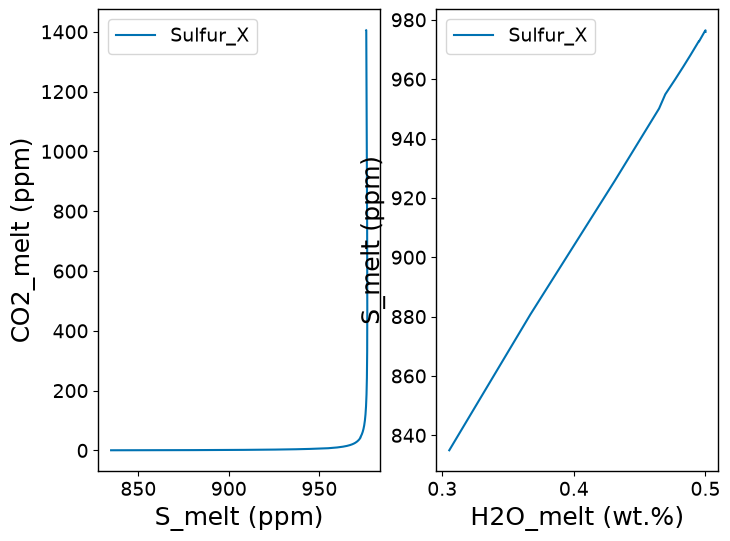

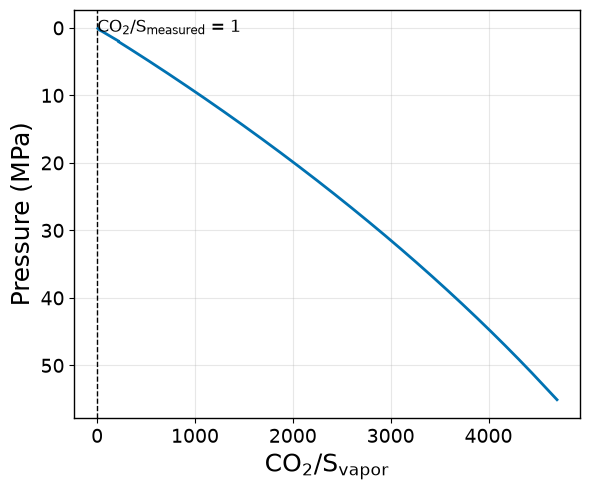

In [18]:
%run Sulfur_X-main/main_Fuego.py

In [19]:
# load results from where they are saved
results_degas_sx = pd.read_csv('Sulfur_X-main/results_folder/test_Fuego_closedT'+str(temperature)+'_dFMQ'+str(delta_FMQ)+'_H2O'+str(H2O_initial)+'_CO2'+str(CO2_initial)+'_fO2track.csv')

#### 2.2.4 EVo

EVo models volcanic gas speciation and volume as magma rises from depth toward the surface. Given a magma composition, temperature, fO2, and dissolved volatile contents, EVo tracks how CO2, H2O, SO2, H2S and other species partition between the melt and an exsolving gas phase at each pressure step. 
The following cells are from EVO: a worked example (https://github.com/pipliggins/EVo/tree/main/examples)

## 1. Define the magma composition

The dry (volatile-free) major element composition is provided as a `pd.Series` of oxide weight percents. The example below is basaltic; other example compositions are in `input_files/chem.yaml`.

In [20]:
composition = pd.Series(
    {
        "SIO2": float(ini_comp['SiO2']),
        "TIO2": float(ini_comp['TiO2']),
        "AL2O3": float(ini_comp['Al2O3']),
        "FEO": float(ini_comp['FeO']),
        "MNO": float(ini_comp['MnO']),
        "MGO": float(ini_comp['MgO']),
        "CAO": float(ini_comp['CaO']),
        "NA2O": float(ini_comp['Na2O']),
        "K2O": float(ini_comp['K2O']),
        "P2O5": float(ini_comp['P2O5']),
    }
)


temperature = float(MI.loc[row,'T_C'])

# fO2 relative to FMQ buffer
delta_FMQ = DFMQ

# initial H2O in wt.%
H2O_initial = ini_comp['H2O']

# initial CO2 in ppm
CO2_initial = ini_comp['CO2']

# initial sulfur in ppm
S_initial = float(MI.loc[row,'S_MI_PEC EPMA'])

## 2. Configure the run

All run settings are passed as a second `pd.Series`. The key options are:

| Parameter | Description |
|---|---|
| `GAS_SYS` | Volatile system to model: `oh`, `coh`, `soh`, `cohs`, `cohsn` |
| `FIND_SATURATION` | If `True`, EVo finds the volatile saturation pressure and decompresses from there |
| `FE_SYSTEM` | If `True`, fO2 is buffered by melt Fe2+/Fe3+ exchange |
| `FO2_buffer` / `FO2_buffer_START` | Rock buffer (`IW`, `FMQ`, `NNO`) and log-unit offset |
| `T_START` | Temperature in Kelvin |

The volatile inputs tell EVo the initial dissolved content of the melt. With `FIND_SATURATION = True`, these values determine the saturation pressure — no need to set `P_START`. See `input_files/env.yaml` for the full list of options and defaults.

In [21]:
# Set up fixed model parameters

model = {
    "COMPOSITION": "basalt",
    "FIND_SATURATION": True,
    "GAS_SYS": "cohs",
    "FE_SYSTEM": True,
    "FO2_buffer_SET": True,
    "FH2_SET": False,
    "WTH2O_SET": True,
    "WTCO2_SET": True,
    "SULFUR_SET": True,
}

# Then merge with the input parameters for use with EVo.

# Starting conditions
fo2_buffer = "FMQ"  # reference buffer (IW, FMQ or NNO)
dfo2 =  DFMQ  # offset from buffer in log units
temp_k = float(MI.loc[row,'T_C']) + 273.15  # temperature, K
h2o_wt_perc = ini_comp['H2O']  # dissolved H2O in the melt, wt%
co2_wt_perc = ini_comp['CO2']/10000 # dissolved CO2 in the melt, wt%
s_ppm = float(MI.loc[row,'S_MI_PEC EPMA'])  # dissolved S in the melt, ppm

env = pd.Series(
    model
    | {
        "FO2_buffer": fo2_buffer,
        "FO2_buffer_START": dfo2,
        "T_START": temp_k,
        # Volatile inputs as melt wt fractions (EVo uses wt fraction internally)
        "WTH2O_START": h2o_wt_perc / 100,
        "WTCO2_START": co2_wt_perc / 100,
        "SULFUR_START": s_ppm / 1e6,
    }
)

## 3. Run EVo

`evo.run_evo()` returns a DataFrame for convenient analysis.

<div style="background-color:#fff3cd; border-left:4px solid #ff9800; padding:10px; border-radius:4px;">
<b>🐍 &nbsp;&nbsp; Note! </b><br>EVo has interactive user prompts. You must enter 'Y' to proceed when it prompts you to do so.
</div>

In [23]:
df_evo = evo.run_evo(composition, env)
df_evo

Reading in from:
Output file: None 

Would you like to switch to the Righter et al. (2013) fO2 model? [Y]/n 


Are you sure you want to continue? y/[N] Set parameters:
COMPOSITION = basalt
RUN_TYPE = closed
SINGLE_STEP = False
FIND_SATURATION = True
GAS_SYS = COHS
FE_SYSTEM = True
OCS = False
S_SAT_WARN = False
T_START = 1442.9250000000002
P_START = 3000.0
P_STOP = 1.0
DP_MIN = 1.0
DP_MAX = 100.0
MASS = 100.0
WgT = 0.001
LOSS_FRAC = 0.99
DENSITY_MODEL = spera2000
FO2_MODEL = r2013
FMQ_MODEL = frost1991
H2O_MODEL = burguisser2015
H2_MODEL = gaillard2003
C_MODEL = burguisser2015
CO_MODEL = None
CH4_MODEL = None
SULFIDE_CAPACITY = oneill2020
SULFATE_CAPACITY = nash2019
SCSS = liu2007
N_MODEL = libourel2003
FO2_buffer_SET = True
FO2_buffer = FMQ
FO2_buffer_START = 0.2
FO2_SET = True
FO2_START = 0.0
FH2_SET = False
FH2_START = 0.24
FH2O_SET = False
FH2O_START = 1000.0
FCO2_SET = False
FCO2_START = 0.01
ATOMIC_MASS_SET = False
ATOMIC_H = 550.0
ATOMIC_C = 200.0
ATOMIC_S = 4000.0
ATOMIC_N = 10

,P,FMQ,fo2,F,rho_bulk,rho_melt,Exsol_vol%,Gas_wt,mol_mass,mH2O,...,S2-_melt,S6+_melt,Stot_melt,N_melt,tot_H,tot_C,tot_O_gas,tot_O,tot_S,tot_N
0,1719.148031,0.200000,4.713289e-09,0.014509,3070.839357,3070.839510,0.000005,0.000001,0.043026,0.020325,...,0.097591,9.205420e-09,0.097591,0.0,559.530095,383.101832,5462.074830,46877.708078,975.905443,0.0
1,1719.000000,0.200015,4.713330e-09,0.014509,3025.147130,3025.148489,0.000057,0.000012,0.043026,0.020326,...,0.097591,9.205841e-09,0.097591,0.0,559.530095,383.101832,5462.073753,46877.708078,975.905443,0.0
2,1709.000000,0.200657,4.712021e-09,0.014512,3024.947640,3025.069736,0.005076,0.001028,0.043023,0.020451,...,0.097590,9.220158e-09,0.097590,0.0,559.530095,383.101832,5461.964460,46877.708078,975.905443,0.0
3,1699.000000,0.201277,4.710482e-09,0.014514,3024.746904,3024.990657,0.010119,0.002038,0.043020,0.020576,...,0.097589,9.233703e-09,0.097589,0.0,559.530095,383.101832,5461.861154,46877.708078,975.905442,0.0
4,1689.000000,0.201896,4.708928e-09,0.014517,3024.544605,3024.911475,0.015208,0.003045,0.043017,0.020704,...,0.097588,9.247213e-09,0.097588,0.0,559.530095,383.101832,5461.758248,46877.708077,975.905448,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,5.000000,-0.274531,1.169815e-09,0.011158,166.394246,3042.992723,94.569686,0.541015,0.022806,0.803431,...,0.064744,7.471172e-10,0.064744,0.0,559.530095,383.101832,5592.171819,46877.708078,975.905443,0.0
933,4.000000,-0.319173,1.055355e-09,0.010908,129.326265,3044.578285,95.782770,0.561300,0.022695,0.806739,...,0.062497,6.017735e-10,0.062497,0.0,559.530095,383.101832,5601.931364,46877.708078,975.905443,0.0
934,3.000000,-0.376523,9.246383e-10,0.010596,93.832538,3046.365683,96.942973,0.584524,0.022588,0.809543,...,0.059684,4.554565e-10,0.059684,0.0,559.530095,383.101832,5614.161303,46877.708078,975.905443,0.0
935,2.000000,-0.456916,7.682516e-10,0.010173,60.123366,3048.458043,98.043330,0.612415,0.022488,0.811393,...,0.055851,3.076685e-10,0.055851,0.0,559.530095,383.101832,5630.739161,46877.708078,975.905443,0.0


## 4. Understanding the output

The output DataFrame contains one row per pressure step. With `FIND_SATURATION = True` the first row records conditions at the saturation pressure, and subsequent rows follow decompression. The columns fall into several groups:

| Column(s) | Units | Description |
|---|---|---|
| `P` | bar | Pressure |
| `FMQ` (or `NNO` / `IW`) | log units | fO2 relative to buffer |
| `fo2` | bar | Absolute oxygen fugacity |
| `F` | ratio | Molar Fe2O3/FeO in melt |
| `Gas_wt` | wt% | Exsolved gas weight fraction |
| `Exsol_vol%` | vol% | Exsolved gas volume fraction |
| `mH2O`, `mCO2`, `mSO2`, … | mol fraction | Gas phase speciation |
| `wH2O`, `wCO2`, `wSO2`, … | wt fraction | Gas phase speciation |
| `fH2O`, `fCO2`, `fSO2`, … | bar | Species fugacities |
| `mCO2/SO2`, `mH2S/SO2`, … | — | Molar ratios of gas species |
| `H2O_melt`, `CO2_melt`, `S2-_melt`, … | wt% | Volatiles remaining dissolved in melt |
| `Stot_melt` | wt% | Total dissolved S (S2- + S6+) |
| `tot_H`, `tot_C`, `tot_S`, … | ppm | Total elemental budget (use to check conservation) |
| `rho_melt`, `rho_bulk` | kg/m³ | Melt and bulk densities |

### Plot and compare to data

We can now plot the different degassing calculations and compare the MI and FI data! Let's import the saturation pressure results calculated in notebook 1.

In [29]:
# import melt inclusion dataset with temperatures calculated in notebook 1
results_pvsat_vc = pd.read_csv("output/results_pvsat_vc.csv")
results_pvsat_vf = pd.read_csv("output/results_pvsat_vf.csv")

# if you haven't run notebook 1, you can grab the "answer key" file from here:
# results_pvsat_vc = pd.read_csv("files/results_pvsat_vc.csv")
# results_pvsat_vf = pd.read_csv("files/results_pvsat_vf.csv")

In [30]:
# Are the symbols at S = 0 in the ax4 real? Are they the MG data? Interestingly, neither model fully degassed S in the melt at 1 bar.

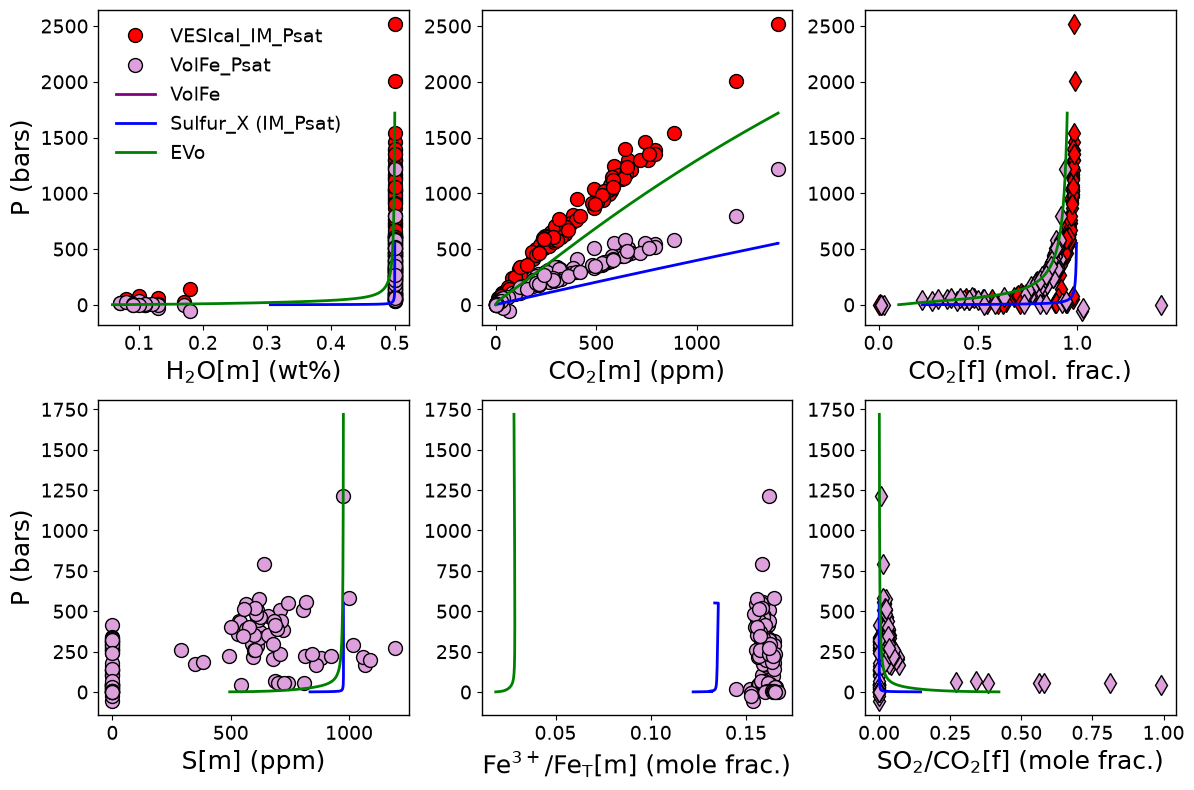

In [31]:
fig, ((ax1, ax2, ax3),(ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12,8))

df = results_pvsat_vc
ax1.plot(df['H2O'], df['SaturationP_bars_VESIcal'], 'ok', mfc='red', label = "VESIcal_IM_Psat")
ax2.plot(df['CO2']*10000, df['SaturationP_bars_VESIcal'], 'ok', mfc='red')
ax3.plot(df['XCO2_fl_VESIcal'], df['SaturationP_bars_VESIcal'], 'dk', mfc='red')

df = results_pvsat_vf
ax1.plot(df['H2OT-eq_wtpc'], df['P_bar'], 'ok', mfc='plum', label = "VolFe_Psat")
ax2.plot(df['CO2T-eq_ppmw'], df['P_bar'], 'ok', mfc='plum')
ax3.plot(df['xgCO2_mf'], df['P_bar'], 'dk', mfc='plum')

ax4.plot(df['ST_ppmw'], df['P_bar'], 'ok', mfc='plum')
ax5.plot(df['Fe3+/FeT'], df['P_bar'], 'ok', mfc="plum")
ax6.plot(df['xgSO2_mf']/df['xgCO2_mf'], df['P_bar'], 'dk', mfc='plum')


df = results_degas_vf
ax1.plot(df['H2OT-eq_wtpc'], df['P_bar'], '-', color='purple', linewidth=2, label = "VolFe")
ax2.plot(df['CO2T-eq_ppmw'], df['P_bar'], '-', color='purple', linewidth=2)
ax3.plot(df['xgCO2_mf'], df['P_bar'], '-', color='purple', linewidth=2)
ax4.plot(df['ST_ppmw'], df['P_bar'], '-', color='purple', linewidth=4)
ax5.plot(df['Fe3+/FeT'], df['P_bar'], '-', color='purple', linewidth=4)
ax6.plot(df['xgSO2_mf']/df['xgCO2_mf'], df['P_bar'], '-', color='purple', linewidth=4)

df = results_degas_sx
ax1.plot(df['wH2O_melt'], df['pressure']*10., '-', color='blue', linewidth=2, label = "Sulfur_X (IM_Psat)")
ax2.plot(df['wCO2_melt'], df['pressure']*10., '-', color='blue', linewidth=2)
ax3.plot(df['XCO2_fluid'], df['pressure']*10., '-', color='blue', linewidth=2)
ax4.plot(df['wS_melt'], df['pressure']*10., '-', color='blue', linewidth=2)
ax5.plot(df['ferric_ratio'], df['pressure']*10., '-', color='blue', linewidth=2)
ax6.plot(df['XSO2_fluid']/df['XCO2_fluid'], df['pressure']*10., '-', color='blue', linewidth=2)

df = df_evo
ax1.plot(df['H2O_melt'], df['P'], '-', color='green', linewidth=2, label = "EVo")
ax2.plot(df['CO2_melt']*10000, df['P'], '-', color='green', linewidth=2)
ax3.plot(df['mCO2'], df['P'], '-', color='green', linewidth=2)
ax4.plot(df['Stot_melt']*10000, df['P'], '-', color='green', linewidth=2)
ax5.plot(2*df['F']/(2*df['F']+1), df['P'], '-', color='green', linewidth=2)
ax6.plot(df['mSO2']/df['mCO2'], df['P'], '-', color='green', linewidth=2)

ax1.set_ylabel('P (bars)')
ax1.set_xlabel('H$_2$O[m] (wt%)')
ax2.set_xlabel('CO$_2$[m] (ppm)')
ax3.set_xlabel('CO$_2$[f] (mol. frac.)')
ax4.set_ylabel('P (bars)')
ax4.set_xlabel('S[m] (ppm)')
ax5.set_xlabel('Fe$^{3+}$/Fe$_T$[m] (mole frac.)')
ax6.set_xlabel('SO$_2$/CO$_2$[f] (mole frac.)')
ax1.legend(frameon=False)
plt.tight_layout()